# exp07 — Replikasi pada empat *forecast origin* dan lima *seed*

Notebook **pelapor**: membaca berkas hasil yang sudah ada, tidak melatih model,
tidak menulis ke `results/`, tidak mengimpor `src/experiments` maupun `tools`.

> **Peringatan reproduksi khusus.** Angka Tabel 5.7 dan Tabel 5.8 **diketik sebagai
> literal** di sumber naskah `content_bab5.py`, bukan dibaca dari CSV. Notebook ini
> karena itu memeriksa **setiap angka** kedua tabel itu satu per satu terhadap
> `exp07_summary_*.csv` — 79 pembandingan pada bagian 6.

## 1. Ringkasan

**Pertanyaan yang dijawab.** RQ2, sumbu *periode uji* dan *inisialisasi acak*.
Hasil utama disertasi bersandar pada **satu** pembagian kronologis per *dataset* dan
**satu** *seed*. Reviewer ronde 2 IJIES (butir R1-6, R2-1, R2-4) mempersoalkan itu.
exp07 mengulang bagian berbasis pohon dari seluruh studi:

- **(a)** pada beberapa *forecast origin* — jendela latih yang memanjang, jendela
  validasi dan uji berpanjang tetap yang bergerak mundur dan tidak pernah bertumpang tindih;
- **(b)** pada beberapa *seed* acak pada pembagian utama.

**Tidak ada ramalan pra-registrasi** untuk exp07; ia dijalankan sebagai tanggapan reviewer,
bukan sebagai uji hipotesis. Statusnya **terbukti** dalam arti klaim ketahanannya didukung
berkas hasil.

**Dipakai di mana.**

| Naskah | Bagian |
|---|---|
| Disertasi | Subbab 5.5, **Tabel 5.7** (Rossmann), **Tabel 5.8** (PharmaSales), **Gambar 5.4** |
| Paper IJIES | **Tabel 7** (ritel) dan **Tabel 11** (data obat) |

## 2. Lingkungan

In [1]:
# Notebook pelapor: HANYA MEMBACA.
# Tidak melatih model, tidak mengimpor src/experiments atau tools (agar TensorFlow
# tidak ikut termuat), dan tidak pernah menulis ke results/, data/ atau raw/.
%matplotlib inline
from pathlib import Path
import ast, json, hashlib, datetime, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cari_root(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / "results").is_dir() and (c / "src" / "experiments").is_dir():
            return c
    raise RuntimeError("root repositori tidak ditemukan dari " + str(p))


ROOT = cari_root(Path.cwd().resolve())
RES = ROOT / "results"

pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.max_rows", 200)

print("Root repositori :", ROOT)
print("Folder hasil    :", RES.relative_to(ROOT),
      f"({sum(1 for f in RES.rglob('*') if f.is_file())} berkas)")
print("Dijalankan      :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


def idn(x, d=2, tanda=False):
    """Format angka gaya Indonesia (koma desimal, titik ribuan)."""
    s = f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    if tanda and x > 0:
        s = "+" + s
    return s.replace("-", "\u2212")


def baca(nama, **kw):
    """Baca satu berkas di results/ sebagai DataFrame. Read-only."""
    f = RES / nama
    if not f.exists():
        raise FileNotFoundError(f"{nama} tidak ada di results/")
    return pd.read_csv(f, **kw)


def potongan(relpath, nama=None, awal=None, akhir=None):
    """Tampilkan potongan kode dengan membaca berkas sebagai TEKS.

    Memakai ``ast`` untuk menemukan batas fungsi/konstanta, sehingga modul
    eksperimen tidak perlu diimpor.
    """
    f = ROOT / relpath
    teks = f.read_text(encoding="utf-8")
    baris = teks.splitlines()
    if nama is not None:
        pohon = ast.parse(teks)
        ketemu = False
        for n in ast.walk(pohon):
            if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and n.name == nama:
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
            if isinstance(n, ast.Assign) and any(getattr(t, "id", None) == nama for t in n.targets):
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
        if not ketemu:
            raise KeyError(f"'{nama}' tidak ditemukan di {relpath}")
    awal = awal or 1
    akhir = akhir or len(baris)
    lebar = len(str(akhir))
    print(f"--- {relpath}:{awal}-{akhir} " + "-" * max(0, 74 - len(relpath)))
    for i in range(awal, akhir + 1):
        print(f"{str(i).rjust(lebar)} | {baris[i - 1]}")


def git(*args):
    """Jalankan perintah git read-only di root repositori."""
    try:
        r = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() if r.returncode == 0 else ""
    except Exception:
        return ""


def asal(nama_meta=None, berkas_hasil=None, skrip=None, log=None):
    """Cetak asal-usul: meta.json, commit, dan log run bila ada."""
    if nama_meta:
        f = RES / nama_meta
        if f.exists():
            print("meta.json " + "-" * 60)
            print(json.dumps(json.loads(f.read_text(encoding="utf-8")), indent=2, ensure_ascii=False))
            print()
    for label, path in [("berkas hasil", berkas_hasil), ("skrip", skrip)]:
        if path:
            print(f"commit terakhir yang menyentuh {label} ({path})")
            print("  " + (git("log", "-1", "--date=short", "--format=%h  %ad  %s", "--", path) or "(tidak terbaca)"))
    if log:
        f = RES / "logs" / log
        print()
        if f.exists():
            print(f"results/logs/{log}  ({f.stat().st_size} bytes, "
                  f"ditulis {datetime.datetime.fromtimestamp(f.stat().st_mtime):%Y-%m-%d %H:%M})")
        else:
            print(f"results/logs/{log} tidak ada di klon ini (berkas *.log diabaikan git).")

Root repositori : I:\Shared drives\Riset S3\Experiment S3 Code\antgravity_riset\AR-LRX_hybrid-forecasting


Folder hasil    : results (179 berkas)
Dijalankan      : 2026-09-29 06:40


In [2]:
# Pembanding angka CSV terhadap angka yang tercetak di disertasi.
# Tidak ada angka yang dibetulkan di sini; ketidakcocokan hanya dilaporkan.
_cek = []


def cek(butir, nilai_csv, nilai_naskah, tol=0.005, d=4, rujukan=""):
    beda = abs(float(nilai_csv) - float(nilai_naskah))
    ok = beda <= tol
    _cek.append({
        "Butir": butir,
        "Rujukan naskah": rujukan,
        "Dari CSV": round(float(nilai_csv), d),
        "Di disertasi": float(nilai_naskah),
        "|selisih|": round(beda, 6),
        "Status": "COCOK" if ok else "TIDAK COCOK",
    })
    return ok


def laporan_cek():
    t = pd.DataFrame(_cek)
    n_ok = int((t.Status == "COCOK").sum())
    display(t)
    print()
    print(f"RINGKASAN: {n_ok} dari {len(t)} angka COCOK dengan naskah disertasi.")
    buruk = t[t.Status == "TIDAK COCOK"]
    if len(buruk):
        print()
        print("!" * 78)
        print("ADA ANGKA YANG TIDAK COCOK. Tidak dibetulkan di notebook ini.")
        print("Laporkan butir berikut sebelum notebook dipakai sebagai lampiran:")
        for _, r in buruk.iterrows():
            print(f"  - {r.Butir} ({r['Rujukan naskah']}): "
                  f"CSV {r['Dari CSV']} vs naskah {r['Di disertasi']}")
        print("!" * 78)
    else:
        print("Tidak ada selisih di luar toleransi pembulatan.")
    return t

## 3. Desain eksperimen

**Protokol tidak diubah sama sekali**: residual *cross-fitted*, penyetelan hanya pada
validasi, refit pada latih + validasi, blok uji disentuh sekali (kontrak C1–C8).

**Rossmann.** Varian `V3_sales_lagged`. Empat *origin* dengan blok uji 42 hari yang
berakhir 31 Juli, 19 Juni, 8 Mei, dan 27 Maret 2015. Lima *seed*: 42, 1, 2, 3, 4.

**PharmaSales.** Empat *origin* dengan blok uji 90 hari (harian) atau 13 minggu (mingguan),
blok validasi 180 hari / 26 minggu, pada 32 konfigurasi. Lima *seed* yang sama.

Konstanta rancangan, dibaca sebagai teks dari skripnya:

In [3]:
potongan("tools/exp07_rolling_origin.py", awal=77, akhir=86)

--- tools/exp07_rolling_origin.py:77-86 ---------------------------------------------
77 | VARIANT = "V3_sales_lagged"
78 | ROSS_TEST_DAYS, ROSS_VAL_DAYS, ROSS_ORIGINS = 42, 84, 4
79 | PH_TEST = {"daily": 90, "weekly": 13}
80 | PH_VAL = {"daily": 180, "weekly": 26}
81 | PH_ORIGINS = 4
82 | SEEDS = [42, 1, 2, 3, 4]
83 | CATEGORIES = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
84 | GRANS = [("daily", "data/raw/pharma-sales/salesdaily.csv", 7),
85 |          ("weekly", "data/raw/pharma-sales/salesweekly.csv", 52)]
86 | 


**Model neural tidak diikutkan.** exp07 mengulang bagian **berbasis pohon** saja. Dua
alasannya tertulis di *docstring* skripnya (`tools/exp07_rolling_origin.py` baris 15–16):
biayanya dua orde besaran lebih tinggi, dan model neural tidak reproduksi bit-per-bit
pada CPU.

**Besaran baru yang dicatat.** Selain RMSE uji, exp07 mencatat `resid_test_r2` —
R² tahap kedua pada residual **blok uji**, yang tidak berperan dalam seleksi apa pun.
Inilah yang membuat label kondisi residual dapat diuji pada data yang benar-benar disisihkan:

In [4]:
potongan("tools/exp07_rolling_origin.py", nama="resid_test_r2")

--- tools/exp07_rolling_origin.py:109-116 ---------------------------------------------
109 | def resid_test_r2(row, y_test):
110 |     """R^2 of the fitted residual learner on TEST residuals (never used for selection)."""
111 |     if "_stage1_test_raw" not in row or "_test_correction" not in row:
112 |         return np.nan
113 |     r = np.asarray(y_test, float) - np.asarray(row["_stage1_test_raw"], float)
114 |     c = np.asarray(row["_test_correction"], float)
115 |     ss = float(np.sum((r - r.mean()) ** 2))
116 |     return 1.0 - float(np.sum((r - c) ** 2)) / ss if ss > 0 else np.nan


## 4. Asal-usul hasil

In [5]:
RUN_EXPERIMENT = False

PERINTAH = [
    "python tools/exp07_rolling_origin.py --part rossmann-origins",
    "python tools/exp07_rolling_origin.py --part rossmann-seeds",
    "python tools/exp07_rolling_origin.py --part pharma-origins",
    "python tools/exp07_rolling_origin.py --part pharma-seeds",
    "python tools/exp07_rolling_origin.py --part summary",
]

if RUN_EXPERIMENT:
    for c in PERINTAH:
        print(">>", c)
        r = subprocess.run(c, shell=True, cwd=ROOT)
        print("   kode keluar:", r.returncode)
else:
    print("RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.")
    print()
    print("Perintah asli yang menghasilkan berkas di results/:")
    for c in PERINTAH:
        print("   ", c)
    print()
    print('Runtime asli sekitar 6-7 jam, dibagi empat bagian. Setiap bagian menyimpan checkpoint dan dapat dilanjutkan dengan perintah yang sama.')

RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.

Perintah asli yang menghasilkan berkas di results/:
    python tools/exp07_rolling_origin.py --part rossmann-origins
    python tools/exp07_rolling_origin.py --part rossmann-seeds
    python tools/exp07_rolling_origin.py --part pharma-origins
    python tools/exp07_rolling_origin.py --part pharma-seeds
    python tools/exp07_rolling_origin.py --part summary

Runtime asli sekitar 6-7 jam, dibagi empat bagian. Setiap bagian menyimpan checkpoint dan dapat dilanjutkan dengan perintah yang sama.


In [6]:
asal(berkas_hasil="results/exp07_summary_rossmann_origins.csv",
     skrip="tools/exp07_rolling_origin.py")
print()
print("Berkas hasil exp07 di results/:")
for f in sorted(RES.glob("exp07_*")):
    if f.is_file():
        print(f"  {f.name:44s} {f.stat().st_size/1024:9.1f} KB")
    else:
        print(f"  {f.name:44s} (folder, {sum(1 for _ in f.rglob('*') if _.is_file())} berkas prediksi)")

commit terakhir yang menyentuh berkas hasil (results/exp07_summary_rossmann_origins.csv)


  d48a0c8  2026-09-17  Enable LightGBM row bagging in the baseline and re-run dependent analyses; add exp08 and helper scripts
commit terakhir yang menyentuh skrip (tools/exp07_rolling_origin.py)


  d48a0c8  2026-09-17  Enable LightGBM row bagging in the baseline and re-run dependent analyses; add exp08 and helper scripts

Berkas hasil exp07 di results/:
  exp07_pharma_origins.csv                         577.7 KB
  exp07_pharma_origins_predictions             (folder, 4 berkas prediksi)
  exp07_pharma_seeds.csv                           719.5 KB
  exp07_pharma_seeds_predictions               (folder, 5 berkas prediksi)
  exp07_rossmann_origins.csv                        28.5 KB
  exp07_rossmann_origins_predictions           (folder, 4 berkas prediksi)
  exp07_rossmann_seeds.csv                          22.0 KB
  exp07_rossmann_seeds_predictions             (folder, 4 berkas prediksi)
  exp07_summary_pharma_origins.csv                   1.7 KB
  exp07_summary_pharma_seeds.csv                     1.9 KB
  exp07_summary_rossmann_origins.csv                 2.9 KB
  exp07_summary_rossmann_seeds.csv                   2.9 KB


## 5. Hasil

### 5.1 Rossmann — Tabel 5.7

"Model pohon terbaik" dihitung ulang di sini: RMSE terkecil di antara XGBoost,
XGBoost (grid Zhao) dan LightGBM (Zeng) pada tiap pembagian, dan Δ adalah selisih
AR-LRX *augmented* (S₁ struktural) terhadap model itu.

In [7]:
ro = baca("exp07_summary_rossmann_origins.csv")
rs = baca("exp07_summary_rossmann_seeds.csv")

POHON = ["XGBoost", "XGBoost (grid Zhao)", "LightGBM (Zeng)"]
A = "AR-LRX-Aug [structural]"
AL = "AR-LRX-Aug [struct_linear]"


def ringkas(df, label_map):
    """Susun ulang Tabel 5.7: model pohon terbaik per pembagian dan selisihnya."""
    out = []
    for _, r in df.iterrows():
        rmse_pohon = {m: r[f"RMSE | {m}"] for m in POHON if f"RMSE | {m}" in r}
        terbaik = min(rmse_pohon, key=rmse_pohon.get)
        out.append({
            "Pembagian": label_map[r.group],
            f"AR-LRX aug., S1 struktural": r[f"RMSE | {A}"],
            f"AR-LRX aug., S1 struct_linear": r[f"RMSE | {AL}"],
            "Model pohon terbaik": terbaik,
            "RMSE pohon terbaik": rmse_pohon[terbaik],
            "Delta (%)": r[f"AugStruct vs {terbaik} (%)"],
            "R2res uji": r.get(f"resid_test_r2 | {A}", np.nan),
        })
    return pd.DataFrame(out)


lab_o = {"origin0": "Origin 1", "origin1": "Origin 2", "origin2": "Origin 3", "origin3": "Origin 4"}
lab_s = {"seed42": "Seed 42", "seed1": "Seed 1", "seed2": "Seed 2", "seed3": "Seed 3", "seed4": "Seed 4"}
t57 = pd.concat([ringkas(ro, lab_o),
                 ringkas(rs.set_index("group").loc[list(lab_s)].reset_index(), lab_s)],
                ignore_index=True)

tampil = t57.copy()
for c in ["AR-LRX aug., S1 struktural", "AR-LRX aug., S1 struct_linear", "RMSE pohon terbaik"]:
    tampil[c] = tampil[c].round(2)
tampil["Delta (%)"] = tampil["Delta (%)"].round(2)
tampil["R2res uji"] = tampil["R2res uji"].round(2)
display(tampil)
print()
print("Peringkat AR-LRX-Aug [structural] pada tiap pembagian:")
print(pd.concat([ro[["group", "best_model", "rank_AR-LRX-Aug_structural"]],
                 rs[["group", "best_model", "rank_AR-LRX-Aug_structural"]]]).to_string(index=False))

,Pembagian,"AR-LRX aug., S1 struktural","AR-LRX aug., S1 struct_linear",Model pohon terbaik,RMSE pohon terbaik,Delta (%),R2res uji
0,Origin 1,920.46,916.69,XGBoost (grid Zhao),966.32,-4.75,0.33
1,Origin 2,872.59,874.14,XGBoost (grid Zhao),957.10,-8.83,0.29
2,Origin 3,1123.80,1098.10,XGBoost (grid Zhao),1140.43,-1.46,0.47
3,Origin 4,780.95,779.30,LightGBM (Zeng),853.90,-8.54,0.19
4,Seed 42,954.90,961.34,LightGBM (Zeng),1009.99,-5.45,NaN
5,Seed 1,952.69,947.19,LightGBM (Zeng),1014.50,-6.09,0.37
6,Seed 2,954.16,948.26,LightGBM (Zeng),1015.31,-6.02,0.38
7,Seed 3,952.61,949.66,XGBoost (grid Zhao),1012.17,-5.88,0.38
8,Seed 4,943.78,948.59,LightGBM (Zeng),1015.20,-7.04,0.39



Peringkat AR-LRX-Aug [structural] pada tiap pembagian:
  group                 best_model  rank_AR-LRX-Aug_structural
origin0 AR-LRX-Aug [struct_linear]                           2
origin1    AR-LRX-Aug [structural]                           1
origin2 AR-LRX-Aug [struct_linear]                           2
origin3 AR-LRX-Aug [struct_linear]                           2
  seed1 AR-LRX-Aug [struct_linear]                           2
  seed2 AR-LRX-Aug [struct_linear]                           2
  seed3 AR-LRX-Aug [struct_linear]                           2
  seed4    AR-LRX-Aug [structural]                           1
 seed42    AR-LRX-Aug [structural]                           1


### 5.2 PharmaSales — Tabel 5.8

In [8]:
po = baca("exp07_summary_pharma_origins.csv")
ps = baca("exp07_summary_pharma_seeds.csv")
ph = pd.concat([po.assign(_lab=po.group.map(lab_o)),
                ps.set_index("group").loc[list(lab_s)].reset_index().assign(
                    _lab=lambda d: d.group.map(lab_s))], ignore_index=True)

t58 = pd.DataFrame({
    "Pembagian": ph._lab,
    "Gerbang tertutup": ph.gate_closed,
    "R2res validasi < 0": ph.resid_val_r2_negative,
    "R2res uji < 0": ph.resid_test_r2_negative,
    "Tanpa gerbang lebih buruk": ph.ungated_worse_than_S1,
    "  rata-rata (%)": ph.ungated_mean_pct.round(2),
    "Bergerbang lebih buruk": ph.gated_worse_than_S1,
    "  rata-rata (%)": ph.gated_mean_pct.round(2),
    "Tanda val/uji sepakat": ph.regime_agree_val_test,
    "Terburuk bergerbang (%)": ph.gated_worst_pct.round(1),
})
display(t58)
print()
print(f"R2res validasi negatif berkisar {ph.resid_val_r2_negative.min()}-{ph.resid_val_r2_negative.max()} dari 32.")
print(f"R2res uji negatif berkisar      {ph.resid_test_r2_negative.min()}-{ph.resid_test_r2_negative.max()} dari 32.")
print(f"Tanda keduanya sepakat pada     {ph.regime_agree_val_test.min()}-{ph.regime_agree_val_test.max()} konfigurasi.")
o, s = ph.iloc[:4], ph.iloc[4:]
print(f"Gerbang tertutup: {o.gate_closed.min()}-{o.gate_closed.max()} antar-origin, "
      f"{s.gate_closed.min()}-{s.gate_closed.max()} antar-seed.")
print(f"Rata-rata pemburukan bergerbang antar-seed: "
      f"{idn(s.gated_mean_pct.min(), 2)}-{idn(s.gated_mean_pct.max(), 2)}%")
print(f"Kasus terburuk bergerbang pada satu origin: {idn(o.gated_worst_pct.max(), 1)}%")

,Pembagian,Gerbang tertutup,R2res validasi < 0,R2res uji < 0,Tanpa gerbang lebih buruk,rata-rata (%),Bergerbang lebih buruk,Tanda val/uji sepakat,Terburuk bergerbang (%)
0,Origin 1,13,26,29,20,0.97,13,25,12.4
1,Origin 2,8,24,29,22,2.02,16,23,14.4
2,Origin 3,2,28,27,19,1.97,16,23,22.2
3,Origin 4,15,27,26,12,-0.20,6,25,4.0
4,Seed 42,17,31,26,19,0.22,8,25,4.5
5,Seed 1,13,31,28,18,0.18,9,27,4.3
6,Seed 2,17,32,27,18,0.15,8,27,1.4
7,Seed 3,13,32,29,17,0.20,8,29,5.6
8,Seed 4,13,30,28,16,0.12,8,26,2.1



R2res validasi negatif berkisar 24-32 dari 32.
R2res uji negatif berkisar      26-29 dari 32.
Tanda keduanya sepakat pada     23-29 konfigurasi.
Gerbang tertutup: 2-15 antar-origin, 13-17 antar-seed.
Rata-rata pemburukan bergerbang antar-seed: 0,12-0,22%
Kasus terburuk bergerbang pada satu origin: 22,2%


### 5.3 Gambar 5.4

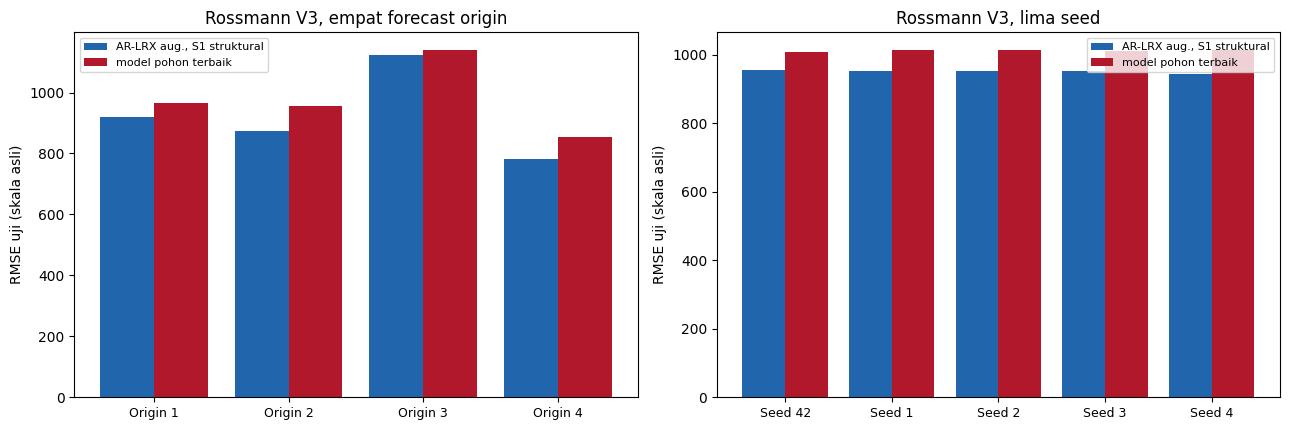

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, (df, lab, judul) in zip(axes, [(ro, lab_o, "empat forecast origin"),
                                        (rs.set_index("group").loc[list(lab_s)].reset_index(),
                                         lab_s, "lima seed")]):
    x = np.arange(len(df))
    pohon_rmse = [min(r[f"RMSE | {m}"] for m in POHON if f"RMSE | {m}" in r) for _, r in df.iterrows()]
    ax.bar(x - 0.2, df[f"RMSE | {A}"], 0.4, label="AR-LRX aug., S1 struktural", color="#2166ac")
    ax.bar(x + 0.2, pohon_rmse, 0.4, label="model pohon terbaik", color="#b2182b")
    ax.set_xticks(x); ax.set_xticklabels([lab[g] for g in df.group], fontsize=9)
    ax.set_ylabel("RMSE uji (skala asli)")
    ax.set_title(f"Rossmann V3, {judul}")
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 6. Cek kecocokan dengan angka disertasi

Bagian terpenting notebook ini. Karena Tabel 5.7 dan 5.8 ditulis literal di naskah,
tidak ada jaminan otomatis bahwa keduanya masih cocok dengan `results/`.
Setiap sel tabel diperiksa terpisah.

In [10]:
# --- Tabel 5.7: setiap angka LITERAL di content_bab5.py diperiksa satu per satu ---
T57_NASKAH = {
 "Origin 1": (920.46, 916.69, 966.32, -4.75, 0.33),
 "Origin 2": (872.59, 874.14, 957.10, -8.83, 0.29),
 "Origin 3": (1123.80, 1098.10, 1140.43, -1.46, 0.47),
 "Origin 4": (780.95, 779.30, 853.90, -8.54, 0.19),
 "Seed 42":  (954.90, 961.34, 1009.99, -5.45, None),
 "Seed 1":   (952.69, 947.19, 1014.50, -6.09, 0.37),
 "Seed 2":   (954.16, 948.26, 1015.31, -6.02, 0.38),
 "Seed 3":   (952.61, 949.66, 1012.17, -5.88, 0.38),
 "Seed 4":   (943.78, 948.59, 1015.20, -7.04, 0.39),
}
t = t57.set_index("Pembagian")
for k, (a, b, c, dlt, r2) in T57_NASKAH.items():
    row = t.loc[k]
    cek(f"Tabel 5.7 {k}: AR-LRX aug. S1 struktural", row["AR-LRX aug., S1 struktural"], a,
        tol=0.005, rujukan="Tabel 5.7")
    cek(f"Tabel 5.7 {k}: AR-LRX aug. S1 struct_linear", row["AR-LRX aug., S1 struct_linear"], b,
        tol=0.005, rujukan="Tabel 5.7")
    cek(f"Tabel 5.7 {k}: RMSE pohon terbaik", row["RMSE pohon terbaik"], c,
        tol=0.005, rujukan="Tabel 5.7")
    cek(f"Tabel 5.7 {k}: Delta (%)", row["Delta (%)"], dlt, tol=0.005, rujukan="Tabel 5.7")
    if r2 is not None:
        cek(f"Tabel 5.7 {k}: R2res uji", row["R2res uji"], r2, tol=0.005, rujukan="Tabel 5.7")

# --- Tabel 5.8: sama, seluruhnya literal ------------------------------------
T58_NASKAH = {
 "Origin 1": (13, 26, 29, 20, 1.53, 13, 0.97),
 "Origin 2": (8, 24, 29, 22, 3.71, 16, 2.02),
 "Origin 3": (2, 28, 27, 19, 3.63, 16, 1.97),
 "Origin 4": (15, 27, 26, 12, 0.94, 6, -0.20),
 "Seed 42":  (17, 31, 26, 19, 1.77, 8, 0.22),
 "Seed 1":   (13, 31, 28, 18, 1.72, 9, 0.18),
 "Seed 2":   (17, 32, 27, 18, 1.63, 8, 0.15),
 "Seed 3":   (13, 32, 29, 17, 2.00, 8, 0.20),
 "Seed 4":   (13, 30, 28, 16, 1.37, 8, 0.12),
}
u = ph.set_index("_lab")
for k, (gc, rvn, rtn, uw, um, gw, gm) in T58_NASKAH.items():
    r = u.loc[k]
    cek(f"Tabel 5.8 {k}: gerbang tertutup", r.gate_closed, gc, tol=0, rujukan="Tabel 5.8")
    cek(f"Tabel 5.8 {k}: R2res validasi < 0", r.resid_val_r2_negative, rvn, tol=0, rujukan="Tabel 5.8")
    cek(f"Tabel 5.8 {k}: R2res uji < 0", r.resid_test_r2_negative, rtn, tol=0, rujukan="Tabel 5.8")
    cek(f"Tabel 5.8 {k}: tanpa gerbang lebih buruk (n)", r.ungated_worse_than_S1, uw, tol=0, rujukan="Tabel 5.8")
    cek(f"Tabel 5.8 {k}: tanpa gerbang rata-rata (%)", r.ungated_mean_pct, um, tol=0.005, rujukan="Tabel 5.8")
    cek(f"Tabel 5.8 {k}: bergerbang lebih buruk (n)", r.gated_worse_than_S1, gw, tol=0, rujukan="Tabel 5.8")
    cek(f"Tabel 5.8 {k}: bergerbang rata-rata (%)", r.gated_mean_pct, gm, tol=0.005, rujukan="Tabel 5.8")

# --- Angka dalam prosa Subbab 5.5 -------------------------------------------
cek("Subbab 5.5.1: Delta terkecil antar-origin (%)", t57.iloc[:4]["Delta (%)"].max(), -1.46,
    tol=0.005, rujukan="Subbab 5.5.1")
cek("Subbab 5.5.1: Delta terbesar antar-origin (%)", t57.iloc[:4]["Delta (%)"].min(), -8.83,
    tol=0.005, rujukan="Subbab 5.5.1")
cek("Subbab 5.5.1: Delta terkecil antar-seed (%)", t57.iloc[4:]["Delta (%)"].max(), -5.45,
    tol=0.005, rujukan="Subbab 5.5.1")
cek("Subbab 5.5.1: Delta terbesar antar-seed (%)", t57.iloc[4:]["Delta (%)"].min(), -7.04,
    tol=0.005, rujukan="Subbab 5.5.1")
cek("Subbab 5.5.1: R2res uji minimum antar-origin", ro[f"resid_test_r2 | {A}"].min(), 0.19,
    tol=0.005, rujukan="Subbab 5.5.1")
cek("Subbab 5.5.1: R2res uji maksimum antar-origin", ro[f"resid_test_r2 | {A}"].max(), 0.47,
    tol=0.005, rujukan="Subbab 5.5.1")
cek("Subbab 5.5.2: R2res validasi negatif, minimum", ph.resid_val_r2_negative.min(), 24, tol=0,
    rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: R2res validasi negatif, maksimum", ph.resid_val_r2_negative.max(), 32, tol=0,
    rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: R2res uji negatif, minimum", ph.resid_test_r2_negative.min(), 26, tol=0,
    rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: R2res uji negatif, maksimum", ph.resid_test_r2_negative.max(), 29, tol=0,
    rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: tanda sepakat, minimum", ph.regime_agree_val_test.min(), 23, tol=0, rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: tanda sepakat, maksimum", ph.regime_agree_val_test.max(), 29, tol=0, rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: gerbang tertutup antar-origin, minimum", po.gate_closed.min(), 2, tol=0, rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: gerbang tertutup antar-origin, maksimum", po.gate_closed.max(), 15, tol=0, rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: kasus terburuk bergerbang pada satu origin (%)", po.gated_worst_pct.max(), 22.2,
    tol=0.05, rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: rata-rata pemburukan antar-seed, minimum (%)", ps.gated_mean_pct.min(), 0.12,
    tol=0.005, rujukan="Subbab 5.5.2")
cek("Subbab 5.5.2: rata-rata pemburukan antar-seed, maksimum (%)", ps.gated_mean_pct.max(), 0.22,
    tol=0.005, rujukan="Subbab 5.5.2")

hasil_cek = laporan_cek()

,Butir,Rujukan naskah,Dari CSV,Di disertasi,|selisih|,Status
0,Tabel 5.7 Origin 1: AR-LRX aug. S1 struktural,Tabel 5.7,920.4642,920.46,0.004178,COCOK
1,Tabel 5.7 Origin 1: AR-LRX aug. S1 struct_linear,Tabel 5.7,916.6929,916.69,0.002907,COCOK
2,Tabel 5.7 Origin 1: RMSE pohon terbaik,Tabel 5.7,966.3183,966.32,0.001682,COCOK
3,Tabel 5.7 Origin 1: Delta (%),Tabel 5.7,-4.7452,-4.75,0.004758,COCOK
4,Tabel 5.7 Origin 1: R2res uji,Tabel 5.7,0.3300,0.33,0.000016,COCOK
5,Tabel 5.7 Origin 2: AR-LRX aug. S1 struktural,Tabel 5.7,872.5940,872.59,0.003996,COCOK
6,Tabel 5.7 Origin 2: AR-LRX aug. S1 struct_linear,Tabel 5.7,874.1368,874.14,0.003184,COCOK
7,Tabel 5.7 Origin 2: RMSE pohon terbaik,Tabel 5.7,957.0971,957.10,0.002935,COCOK
8,Tabel 5.7 Origin 2: Delta (%),Tabel 5.7,-8.8291,-8.83,0.000899,COCOK
9,Tabel 5.7 Origin 2: R2res uji,Tabel 5.7,0.2898,0.29,0.000183,COCOK



RINGKASAN: 124 dari 124 angka COCOK dengan naskah disertasi.
Tidak ada selisih di luar toleransi pembulatan.


## 7. Interpretasi dan keterbatasan

**Rossmann.** Salah satu varian AR-LRX *augmented* menjadi model paling akurat pada
**setiap** *origin* dan **setiap** *seed*. Selisih varian struktural terhadap model pohon
terbaik yang dilatih ulang berkisar −1,46% sampai −8,83% antar-*origin* dan −5,45% sampai
−7,04% antar-*seed*. Urutan kedua varian *augmented* berganti dari satu pembagian ke
pembagian lain, yang mendukung perlakuan keduanya sebagai setara. Pemodel residual
menjelaskan 0,19 sampai 0,47 varians residual **uji**, sehingga Rossmann tetap berada pada
kondisi residual berstruktur pada data yang tidak dipakai untuk seleksi apa pun.

**PharmaSales.** Label kondisi residual stabil: R²res validasi negatif pada 24 sampai 32
dari 32 konfigurasi, dan pada residual uji 26 sampai 29. Tanda keduanya sepakat pada 23
sampai 29 konfigurasi — sebagian besar, tetapi **tidak semua**.

**Gerbang kurang stabil daripada label kondisi residual.** Jumlah konfigurasi dengan gerbang
tertutup berkisar 2 sampai 15 antar-*origin*, karena blok validasi rancangan bergulir yang
lebih pendek membuat perbaikan validasi semu lebih mungkin muncul. Terhadap *seed*, gerbang
jauh lebih stabil (rata-rata pemburukan 0,12–0,22%). Jadi ketidakstabilan gerbang terutama
berasal dari **pilihan periode validasi**, bukan dari keacakan pelatihan.

**Keterbatasan.**

1. Model neural tidak diikutkan, sehingga klaim ketahanan hanya berlaku untuk perbandingan
   terhadap model pohon.
2. Empat *origin* semuanya di dalam rentang data yang sama; ini bukan uji ketahanan lintas
   tahun atau lintas rezim permintaan.
3. Kasus terburuk bergerbang mencapai 22,2% pada satu *origin* — gerbang mengurangi, tetapi
   tidak menghilangkan, risiko pemburukan.
4. `resid_test_r2` tidak tercatat pada run *seed* 42 yang asli, sehingga satu sel Tabel 5.7
   berisi tanda hubung. Ini perbedaan pencatatan, bukan hasil yang hilang.

## 8. Pertanyaan yang mungkin diajukan promotor

**1. "Hasil utama hanya dari satu pembagian data. Bagaimana kalau itu kebetulan?"**
Justru itu yang diuji exp07. Pada sembilan pembagian berbeda — empat *origin* dan lima
*seed* — salah satu varian AR-LRX *augmented* selalu menjadi model paling akurat pada
Rossmann. Keunggulannya tidak pernah hilang; besarnya bervariasi antara 1,46% dan 8,83%.

**2. "Mengapa angka Tabel 5.7 dan 5.8 tidak dibaca langsung dari CSV seperti tabel lain?"**
Ini memang kelemahan jejak naskah, dan saya tidak menutupinya. `content_bab5.py` hanya
memanggil `read_csv` untuk empat berkas; kedua tabel exp07 diketik manual. Bagian 6 notebook
ini menutup celah itu dengan memeriksa setiap angkanya terhadap `exp07_summary_*.csv`.

**3. "Gerbang ternyata tidak stabil. Apakah itu tidak melemahkan klaim?"**
Melemahkan klaim tentang *gerbang*, bukan tentang *label kondisi residual*. Keduanya
dibedakan dengan sengaja: label kondisi residual stabil (24–32 dari 32), gerbang tidak
(2–15 antar-*origin*). Disertasi menyatakannya dalam Subbab 5.5.2 dan menelusuri sebabnya
ke panjang blok validasi, bukan ke keacakan pelatihan — yang didukung oleh kestabilan
gerbang antar-*seed* (8–9 konfigurasi memburuk pada kelima *seed*).

**4. "Mengapa model neural tidak ikut diulang?"**
Dua alasan yang tertulis di *docstring* `tools/exp07_rolling_origin.py` baris 15–16:
biaya komputasinya dua orde besaran lebih tinggi, dan model neural tidak reproduksi
bit-per-bit pada CPU. Konsekuensinya adalah batas klaim: hasil exp07 hanya berlaku untuk
perbandingan terhadap model pohon.

**5. "R²res uji itu apa, dan mengapa penting?"**
R² tahap kedua pada residual blok **uji** — data yang tidak dipakai untuk memilih
hiperparameter, bobot gerbang, maupun apa pun. Pada Rossmann nilainya 0,19–0,47, artinya
residual tahap pertama memang masih memuat struktur yang dapat dipelajari, bukan sekadar
artefak seleksi pada data validasi. Inilah pembeda kondisi residual berstruktur dari
kondisi *noise*, diuji pada data yang benar-benar disisihkan.